# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Eszter B. Bartucz
* Username: ebbartucz
* Student number: s6362311
* Group (AS1, etc.): AS4

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

NameError: name 'make_axes_locatable' is not defined

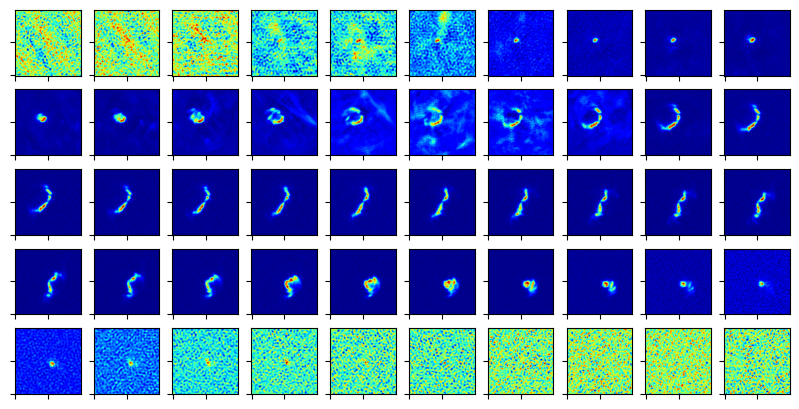

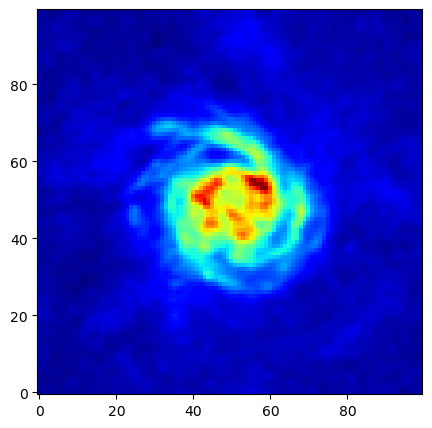

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file
file = fits.open('ngc6946.fits')
hdr = file[0].header

data = file[0].data  # the 0 extension contains the image data

fig = plt.figure(figsize = (10,5))
for i,Z in enumerate(range(1,101,2)): # i is the index of the data in the Z column, Z is the data in the Z column
    frame = fig.add_subplot(5,10,i+1) # making sure mosaic is 5 by 10 
    plt.imshow(data[Z,...], origin = 'lower', cmap = 'jet')
    frame.set_xticklabels([])
    frame.set_yticklabels([])
fig.show

#from the plot we can see that the noisy plots are 1-6 and the last 10. excluding them:

fig2 = plt.figure(figsize = (5,5))
frame2 = fig2.add_subplot(1,1,1)

datanew = 0
for i,Z in enumerate(range(13,81,2)):
    datanew += np.array(data[Z,...]) # summing the channel maps
    
im = frame2.imshow(datanew, origin = 'lower', cmap = 'jet')
divider = make_axes_locatable(frame2)
colbarframe = divider.append_axes('right', size = '5%', pad = 0.15)
fig2.colorbar(im, cax = colorbarframe, label = hdr['BUNIT'])
frame2.set_title('Total HI map')
frame2.set_xlabel(hdr['CTYPE1'])
frame2.set_ylabel(hdr['CTYPE2'])
plt.show()


#plotting a PV map for fixed RA, i.e fixed column:

fig3 = plt.figure(figsize = (5,5))
frame3 = fig3.add_subplot(1,1,1)
frame3.imshow(data[:,50,:], origin = 'lower', cmap = 'jet')
frame3.axvline(40, color = 'red') # plotting the vertical line
frame3.set_title('Position velocity (PV) map')
frame3.set_xlabel(hdr['CTYPE2'])
frame3.set_ylabel(hdr['CTYPE3'])
plt.show()

fig4 = plt.figure(figsize = (4,4))
frame4 = fig4.add_subplot(1,1,1)
frame4.plot(data[:,50,40])
frame4.set_title('Global HI spectral profile')
frame4.set_xlabel(hdr['CTYPE3'])
frame4.set_ylabel(hdr['BUNIT'])
plt.show()

#This profile is the intensity-velocity profile along the plotted vertical line.
#Basically we can imagine this vertical line as looking at the profile from the higher intensity direction
#i.e. the origin (0,0) of the profile plot is at (40,0) of the PV map and profile(100,0) is at PV(40,100).

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

![galaxy_colour.png](attachment:116628c6-fd70-44b6-b939-6d3dc84b26b1.png)
   
**Plot and answer**:

Filename: SDSS_DR17_galaxies.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     20   10000R x 6C   [K, E, E, E, E, E]   
['ObjID', 'u', 'g', 'r', 'i', 'z']


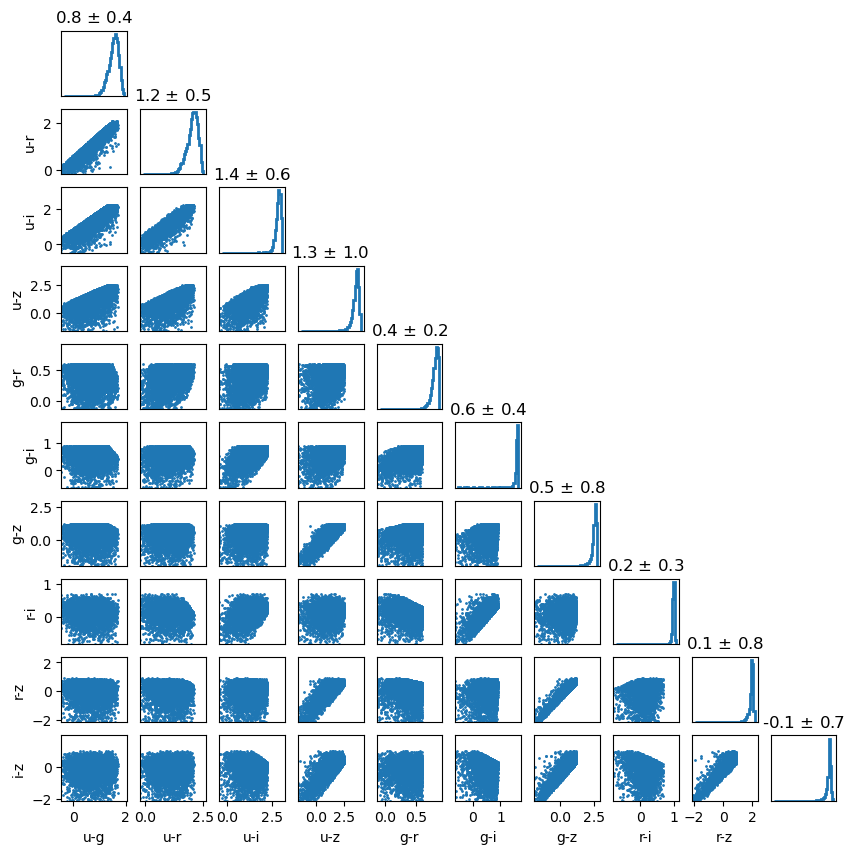

In [4]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt

# Open the FITS file
file = fits.open('SDSS_DR17_galaxies.fits')
file.info()
# Access the data
data = file[1].data  # the first extension contains the table
hdr = file[1].header

colnames = file[1].columns.names # List of the column names
print(colnames)


dfdata = pd.DataFrame(data) # converting to data frame

#filtering out any negative data:
masku = dfdata['u']>=0
maskg = dfdata['g']>=0
maskr = dfdata['r']>=0
maski = dfdata['i']>=0
maskz = dfdata['z']>=0

mask = masku & maskg & maskr & maski & maskz

dfdata = dfdata[mask] # there were no negative values in the data

header = colnames[1::]

for color1 in range (len(header)-1): # calculating color indexes
    for color2 in range (color1+1,len(header)):
        dfdata[header[color1]+'-'+header[color2]] = dfdata[header[color1]]-dfdata[header[color2]]

header = dfdata.keys()[len(header)+1::]

umean = np.mean(np.array(dfdata['u'])) # calculating the mean of each color
gmean = np.mean(np.array(dfdata['g']))
rmean = np.mean(np.array(dfdata['r']))
imean = np.mean(np.array(dfdata['i']))
zmean = np.mean(np.array(dfdata['z']))

fig = plt.figure(figsize = (10,10))
for col in range(len(header)):
    for row in range(col, len(header)):
        frame = fig.add_subplot(10,10,10*row+col+1) # creates vertical numbering --> cornerplot
        if row==col:
            frame.hist(dfdata[header[row]], histtype='step', linewidth = 2, bins = 50) # histograms are in the diagonal of the plot, when row = column
            frame.set_title(rf"{np.mean(np.array(dfdata[header[col]])):.1f} $\pm$ {np.std(np.array(dfdata[header[col]])):.1f}")
            frame.set_xticks([])
            frame.set_yticks([]) # remove unnecessary ticks
            
        if row>col:
            frame.scatter(dfdata[header[col]],dfdata[header[row]],s=1)
            
            std_c = np.std(np.array(dfdata[header[col]])) # setting x limits for columns
            mean_c = np.mean(np.array(dfdata[header[col]]))
            frame.set_xlim(mean_c-3*std_c,mean_c+3*std_c)

            std_r = np.std(np.array(dfdata[header[row]])) # setting y limits for rows
            mean_r = np.mean(np.array(dfdata[header[row]]))
            frame.set_ylim(mean_r-3*std_r,mean_r+3*std_r)
            
            if col != 0:
                frame.set_yticks([])
            if row != (len(header)-1):
                frame.set_xticks([])
            if col == 0:
                frame.set_ylabel(header[row]) # providing necessary axis labels
            if row == (len(header)-1):
                frame.set_xlabel(header[col])

            

In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

![M77.png](attachment:ad565bb5-5f92-4c74-a96a-5cc7a9a786f2.png)

The velocity indicated by the difference between the two wavelengths: 172902.828 m/s.


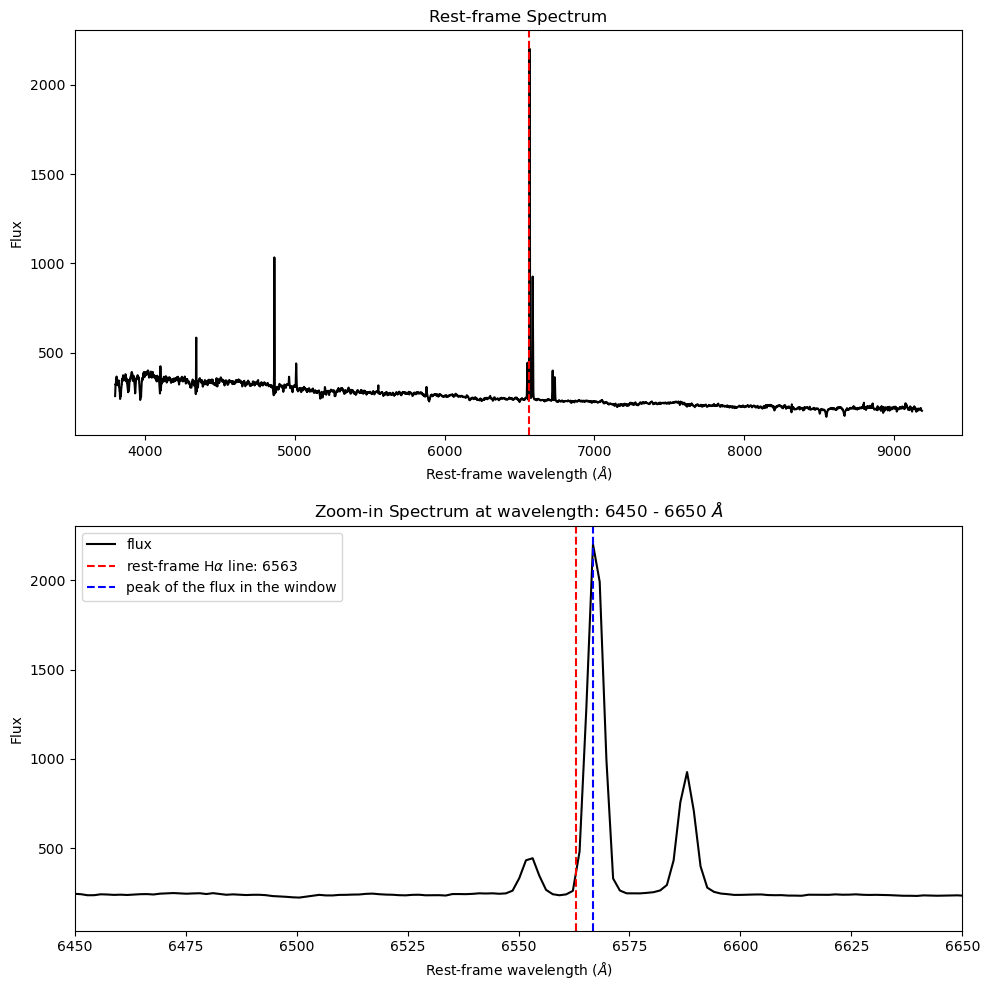

In [6]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from scipy.constants import c
import numpy as np
import matplotlib.pyplot as plt
import math
from math import e

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

query = SDSS.query_region(pos, radius='10 arcsec', spectro=True) # sending query
spectra = SDSS.get_spectra(matches=query)[0]

data = spectra[1].data # extracting data

flux = data['flux']
wavelength = 10**(data['loglam'])

z = 0.0038

rest_wavelength = wavelength/(z+1) # from formula of doppler shift

Halpha = 6563

fig = plt.figure(figsize = (10,10))

frame1 = fig.add_subplot(2,1,1)
frame1.plot(rest_wavelength,flux, color = 'black')
frame1.set_title('Rest-frame Spectrum')
frame1.set_xlabel(r'Rest-frame wavelength ($\AA$)')
frame1.set_ylabel('Flux')
frame1.axvline(Halpha,color = 'red', linestyle = '--')

frame2 = fig.add_subplot(2,1,2)
frame2.plot(rest_wavelength,flux, color = 'black', label = 'flux')
frame2.set_title('Zoom-in Spectrum at wavelength: 6450 - 6650 $\AA$')
frame2.set_xlabel(r'Rest-frame wavelength ($\AA$)')
frame2.set_ylabel('Flux')
frame2.set_xlim(6450,6650)
frame2.axvline(Halpha,color = 'red', linestyle = '--', label = rf"rest-frame H$\alpha$ line: {Halpha}")
frame2.axvline(rest_wavelength[flux==np.max(flux)],color = 'blue', linestyle = '--',label = f"peak of the flux in the window")
frame2.legend(loc = 'upper left')

fig.tight_layout() # making sure there is enough space between the graphs
fig.show()

velocity = ((rest_wavelength[flux==np.max(flux)]-Halpha)/Halpha*c)[0] # to make sure value is not a list
print(f"The velocity indicated by the difference between the two wavelengths: {velocity:.3f} m/s.")

The difference between the two wavelengths might be caused by the cosmological distance of the object, i.e that the universe is acceleratingly expanding, not uniformly, as Hubble's Law would suggest.

In [7]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

/Software/users/modules/9/software/anaconda3/2025.06/lib/python3.13/site-packages/astropy/visualization/stretch.py:543: RuntimeWarning: overflow encountered in sinh
  np.sinh(values, out=values)
/Software/users/modules/9/software/anaconda3/2025.06/lib/python3.13/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


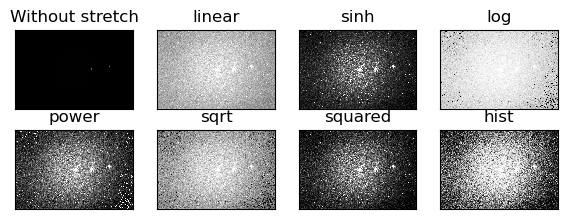

In [8]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

def imdisplay(data,ax,vmin=None,vmax=None,percentlow=1,percenthigh=99,zscale=False,scale='linear',power=1.5,cmap='gray',**kwargs):
    '''
    The function displays a picture created from the inputed data with specified scaling.
    Params: data: (array-like) the data that is used to create the picture
            ax: (object) Axes object from Matplotlib
            vmin: (float) specifies lower bound of range used
            vmax: (float) specifies upper bound of range used
            percentlow: (int) vmin in percentile form
            percenthigh: (int) vmax in percentile form
            zscale: (Bool) find vmin and vmax even if they are set to None
            scale: (str) defines stretch
            power: (float) argument of PowerStretch() if called
            cmap: (str) colormap
    Return: image (Matplotlip plot)
    '''
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)
    
scales = [None,'linear','sinh','log','power','sqrt','squared','hist'] # creating a list of possible values of the scale

file = fits.open('20210422_Li_.00000066.FIT') # opening file
imdata = file[0].data # extracting the data

fig = plt.figure(figsize = (7,5))
for i,s in zip(range(len(scales)),scales):
    frame = fig.add_subplot(len(scales)//2,len(scales)//2,i+1)
    if i == 0:
        frame.imshow(imdata, origin = 'lower', cmap = 'gray') # first plot without stretch, thus using imshow
        s = 'Without stretch'
    else:
        imdisplay(file[0].data,frame,scale = s) # using stretch options suitable for imdisplay
    frame.set_title(s, fontsize = 12)
    frame.set_xticks([])
    frame.set_yticks([])

fig.tight_layout
fig.show()

In [9]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [10]:
from astropy.io import fits
from pathlib import Path
from matplotlib.pyplot import figure, show
import astroalign as aa

directory = '/Users/users/ebbartucz/PROGNUM-repo/Task6/fits/'
excludes = ['BIAS','FLAT','DARK']
path = Path(directory)

lights = [] # list for suitable files
for file in path.iterdir():
    if file.suffix.lower() in ['.fits', '.fit', '.fts']: # only adding files with correct extension, without the excluded criteria
        if not any(ext in file.name for ext in excludes):
            lights.append(file)

lightsdata = [] # data of the selected images
for l in lights:
    image = fits.open(l)
    lightsdata.append(image[0].data.astype('float'))
    image.close()

# stacking:
lightstacked = np.stack(lightsdata) # stacking data

fig = figure()

frame1 = fig.add_subplot(1,2,1)
imdisplay(np.median(lightstacked, axis = 0), frame1) # making sure format is suitable for plotting
frame1.set_title('Lights images stacked')

# aligning then stacking:
frame2 = fig.add_subplot(1,2,2)

target = lights[6] # this is the reference image onto which we align
file = fits.open(target)
targetimage = file[0].data.astype('float')

aligned = []
for l in lights:
    file = fits.open(l)
    tobealigned = file[0].data.astype('float') # load images
    try:
        aligned_im,footprint = aa.register(tobealigned,targetimage,detection_sigma=5.0,max_control_points=50,min_area=5) 
        aligned.append(aligned_im) # append if alignment possible
    except:
        print("Failed!")
    file.close()
    
alignedstacked = np.stack(aligned) # performing stacking again

imdisplay(np.median(alignedstacked, axis = 0), frame2) # making sure it is in suitable format for imdisplay
frame2.set_title('Lights images aligned and stacked')

show()

ModuleNotFoundError: No module named 'astroalign'

IMPORTANT: Jupiter Hub cannot access astroalign through Kapteyn server but it works on an OVirt machine or SSH!!! Please try rerunning my notebook there!

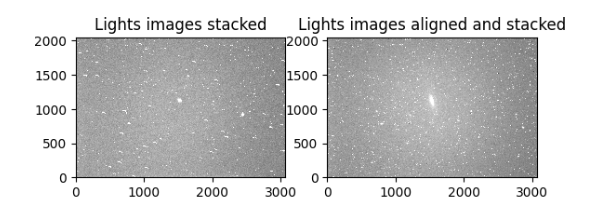

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")